#Global Solution - Prompt and Artificial Intelligence

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

##1. Coleta de dados

In [ ]:
df_interacao = pd.read_csv('dataset_interacao_social(1).csv')
df_crescimento = pd.read_csv('dataset_crescimento_pessoal(1).csv')

In [ ]:
if 'id_pessoa' in df_interacao.columns:
    df_interacao = df_interacao.drop(columns=['id_pessoa'])
if 'id_pessoa' in df_crescimento.columns:
    df_crescimento = df_crescimento.drop(columns=['id_pessoa'])

In [ ]:
df_interacao.head()

,habilidades_de_comunicacao,extroversao,amabilidade,conversacao
0,40.0,47.087657,3.961065,8.692674
1,40.0,37.758144,9.014759,7.142511
2,40.0,34.773852,13.857452,9.526072
3,40.0,40.375627,11.492470,12.265579
4,40.0,24.033706,5.098774,6.556388


In [ ]:
df_crescimento.head()

,estabilidade_emocional,abertura_a_mudanca,autoaperfeicoamento,autotranscendencia,area_carreira
0,74.256741,33.977615,23.051808,20.874560,infraestrutura_e_dados
1,67.254551,35.367760,24.743169,19.642354,infraestrutura_e_dados
2,63.070501,37.512498,28.725345,26.802442,infraestrutura_e_dados
3,69.527972,33.889889,30.656215,25.811944,infraestrutura_e_dados
4,61.938951,31.189647,30.297789,20.728720,infraestrutura_e_dados


In [ ]:
df_inicial = pd.concat([df_interacao.reset_index(drop=True), df_crescimento.reset_index(drop=True)], axis=1)

In [ ]:
atributos_numericos = [
'habilidades_de_comunicacao', 'extroversao', 'amabilidade', 'conversacao',
'estabilidade_emocional', 'abertura_a_mudanca', 'autoaperfeicoamento', 'autotranscendencia'
]

In [ ]:
rotulo = 'area_carreira'

In [ ]:
display(df_inicial.head())

,habilidades_de_comunicacao,extroversao,amabilidade,conversacao,estabilidade_emocional,abertura_a_mudanca,autoaperfeicoamento,autotranscendencia,area_carreira
0,40.0,47.087657,3.961065,8.692674,74.256741,33.977615,23.051808,20.874560,infraestrutura_e_dados
1,40.0,37.758144,9.014759,7.142511,67.254551,35.367760,24.743169,19.642354,infraestrutura_e_dados
2,40.0,34.773852,13.857452,9.526072,63.070501,37.512498,28.725345,26.802442,infraestrutura_e_dados
3,40.0,40.375627,11.492470,12.265579,69.527972,33.889889,30.656215,25.811944,infraestrutura_e_dados
4,40.0,24.033706,5.098774,6.556388,61.938951,31.189647,30.297789,20.728720,infraestrutura_e_dados


##2. Anállise Exploratória de Dados

###2.1 Atributos numéricos para cada classe diferente do rótulo

In [ ]:
descricao_por_classe = df_inicial.groupby(rotulo)[atributos_numericos].describe()
print('Descrição por classe (resumo):')
display(descricao_por_classe)

Descrição por classe (resumo):


habilidades_de_comunicacao             \
                                                             count       mean   
area_carreira                                                                   
desenvolvimento_e_engenharia_de_produto                     2700.0  25.000000   
infraestrutura_e_dados                                      1620.0  25.000000   
negocios_gestao_e_suporte                                   3239.0  30.836678   
seguranca_e_qualidade                                       1620.0  25.000000   

                                                                           \
                                               std  min   25%   50%   75%   
area_carreira                                                               
desenvolvimento_e_engenharia_de_produto  17.081415  0.0  10.0  25.0  40.0   
infraestrutura_e_dados                   17.083525  0.0  10.0  25.0  40.0   
negocios_gestao_e_suporte                20.332570  0.0  10.0  30.0  50.0   
seguranca_e_qualidade                    17.083525  0.0  10.0  25.0  40.0   

                                              extroversao             ...  \
                                          max       count       mean  ...   
area_carreira                                                         ...   
desenvolvimento_e_engenharia_de_produto  50.0      2700.0  33.158192  ...   
infraestrutura_e_dados                   50.0      1620.0  38.658810  ...   
negocios_gestao_e_suporte                60.0      3239.0  45.627884  ...   
seguranca_e_qualidade                    50.0      1620.0  41.545318  ...   

                                        autoaperfeicoamento             \
                                                        75%        max   
area_carreira                                                            
desenvolvimento_e_engenharia_de_produto           32.682997  50.570309   
infraestrutura_e_dados                            34.326640  51.020072   
negocios_gestao_e_suporte                         36.423457  59.472689   
seguranca_e_qualidade                             36.787157  42.527123   

                                        autotranscendencia             \
                                                     count       mean   
area_carreira                                                           
desenvolvimento_e_engenharia_de_produto             2700.0  22.788055   
infraestrutura_e_dados                              1620.0  23.335382   
negocios_gestao_e_suporte                           3239.0  25.149858   
seguranca_e_qualidade                               1620.0  21.977421   

                                                                         \
                                              std        min        25%   
area_carreira                                                             
desenvolvimento_e_engenharia_de_produto  4.759822   5.927818  20.880771   
infraestrutura_e_dados                   4.403560  10.864324  20.728720   
negocios_gestao_e_suporte                6.632377   8.720852  20.111177   
seguranca_e_qualidade                    5.940867   9.345338  18.268266   

                                                                          
                                               50%        75%        max  
area_carreira                                                             
desenvolvimento_e_engenharia_de_produto  22.844563  26.403142  35.941982  
infraestrutura_e_dados                   22.222776  25.811944  42.844228  
negocios_gestao_e_suporte                26.054615  28.350583  50.803407  
seguranca_e_qualidade                    20.390754  26.264602  34.958792  

[4 rows x 64 columns]

In [ ]:
#para melhorar a visualização das classes
descricao_por_classe = df_inicial.groupby(rotulo)[atributos_numericos].describe()
print('\nDescrição por classe (resumo):')
print(descricao_por_classe)


Descrição por classe (resumo):
                                        habilidades_de_comunicacao             \
                                                             count       mean   
area_carreira                                                                   
desenvolvimento_e_engenharia_de_produto                     2700.0  25.000000   
infraestrutura_e_dados                                      1620.0  25.000000   
negocios_gestao_e_suporte                                   3239.0  30.836678   
seguranca_e_qualidade                                       1620.0  25.000000   

                                                                           \
                                               std  min   25%   50%   75%   
area_carreira                                                               
desenvolvimento_e_engenharia_de_produto  17.081415  0.0  10.0  25.0  40.0   
infraestrutura_e_dados                   17.083525  0.0  10.0  25.0  40.0   
negocios_gestao

###2.2 Gráficos

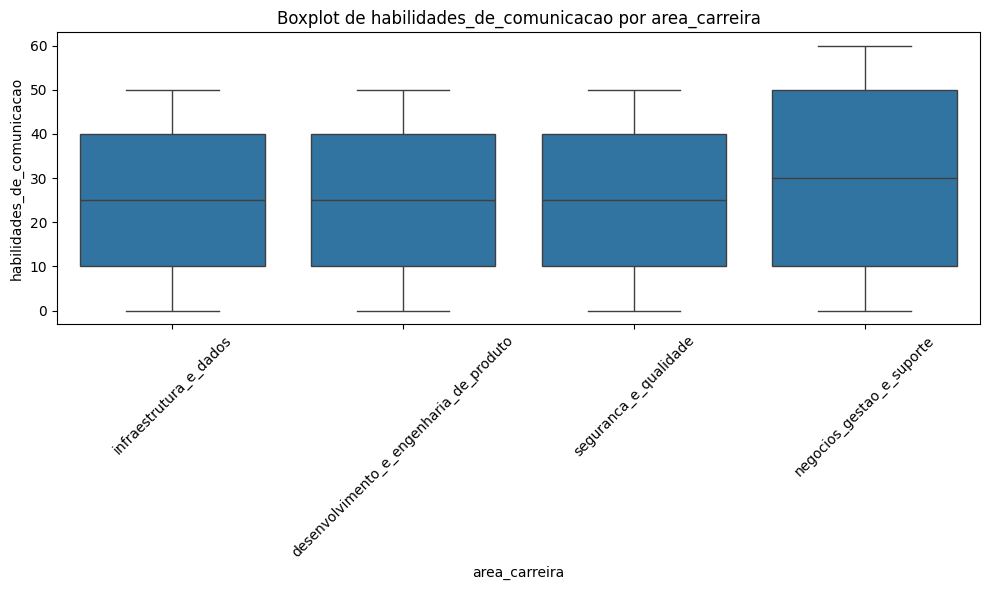

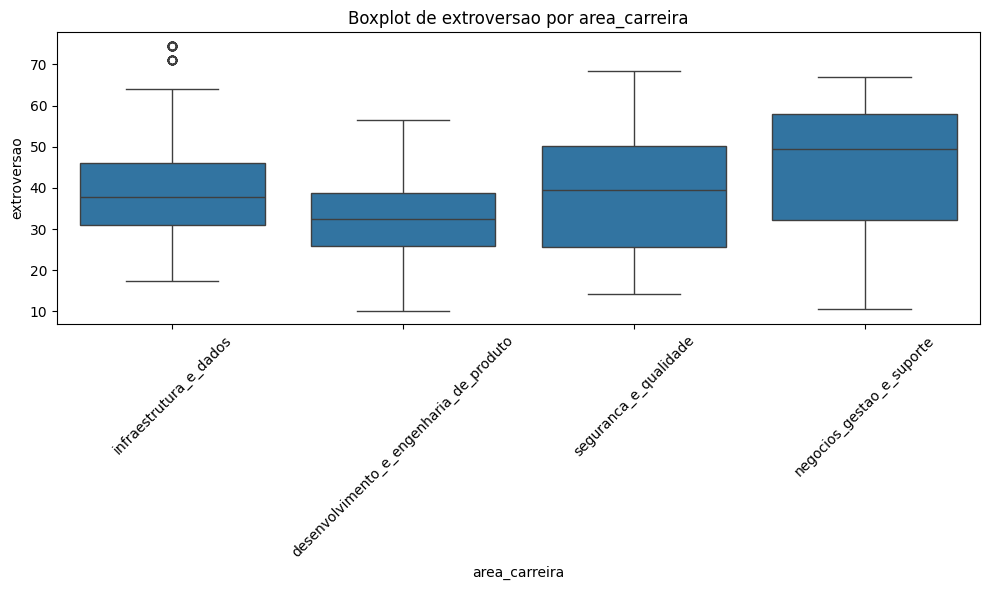

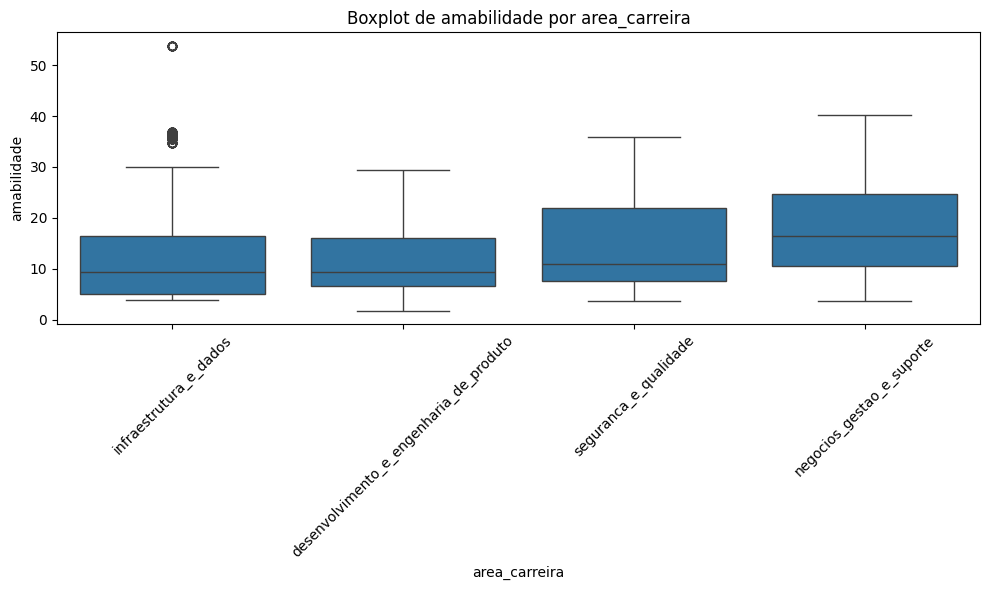

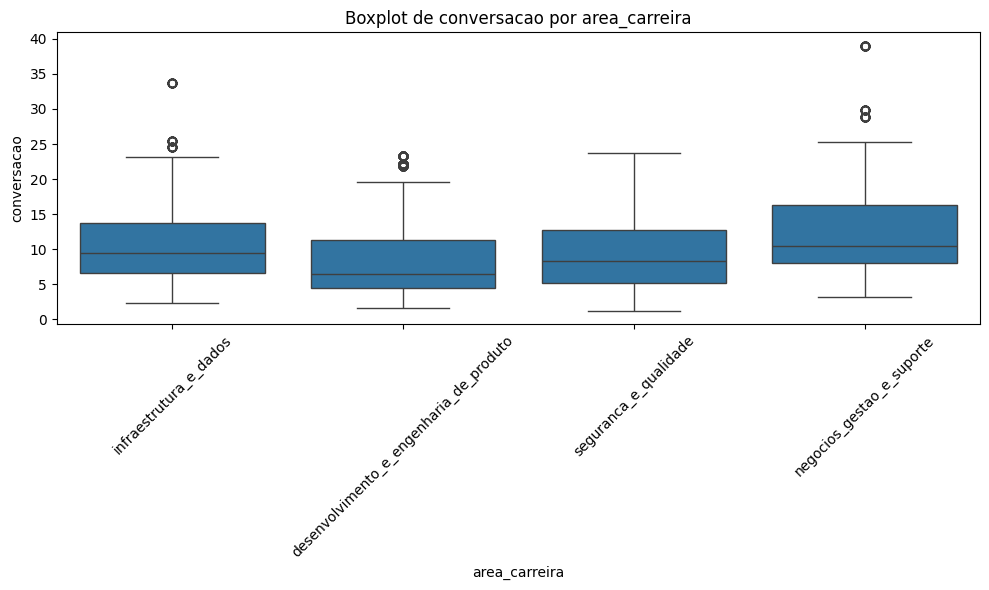

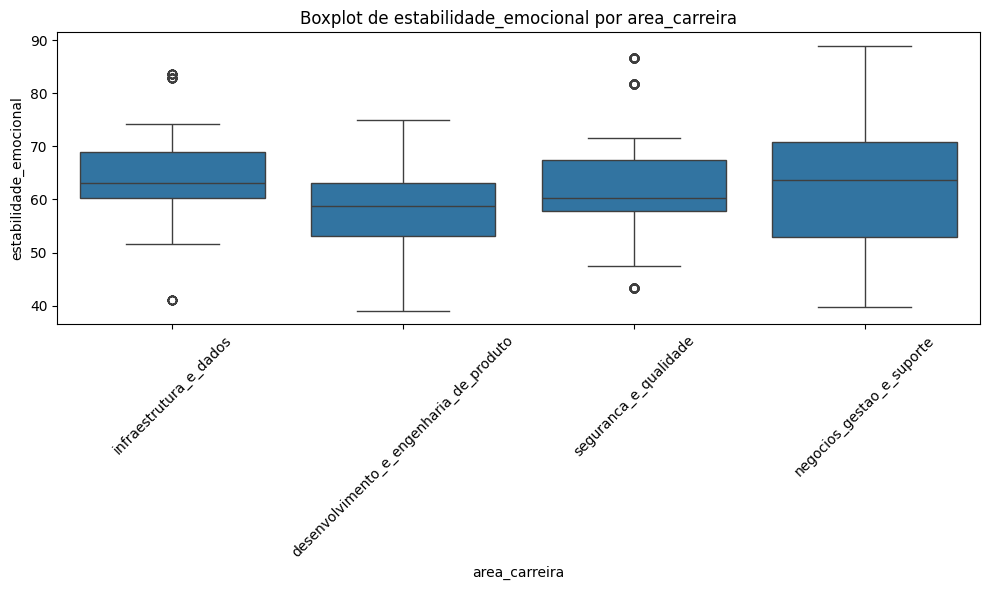

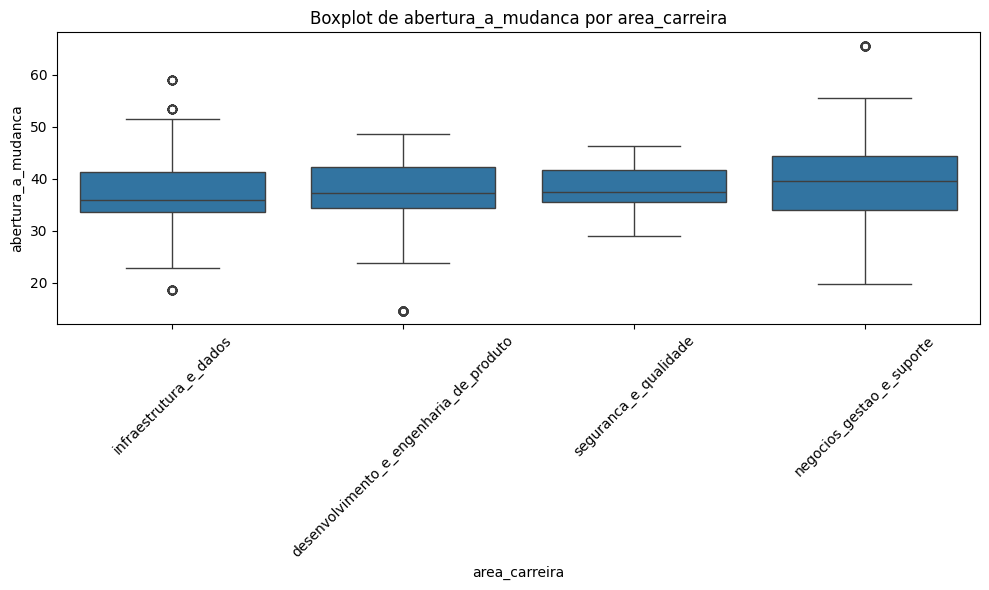

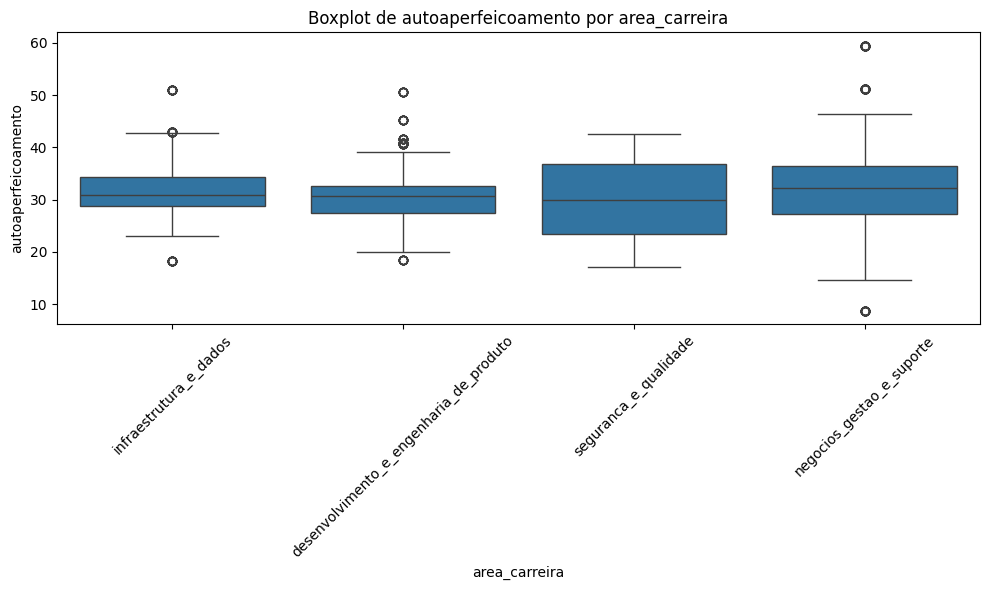

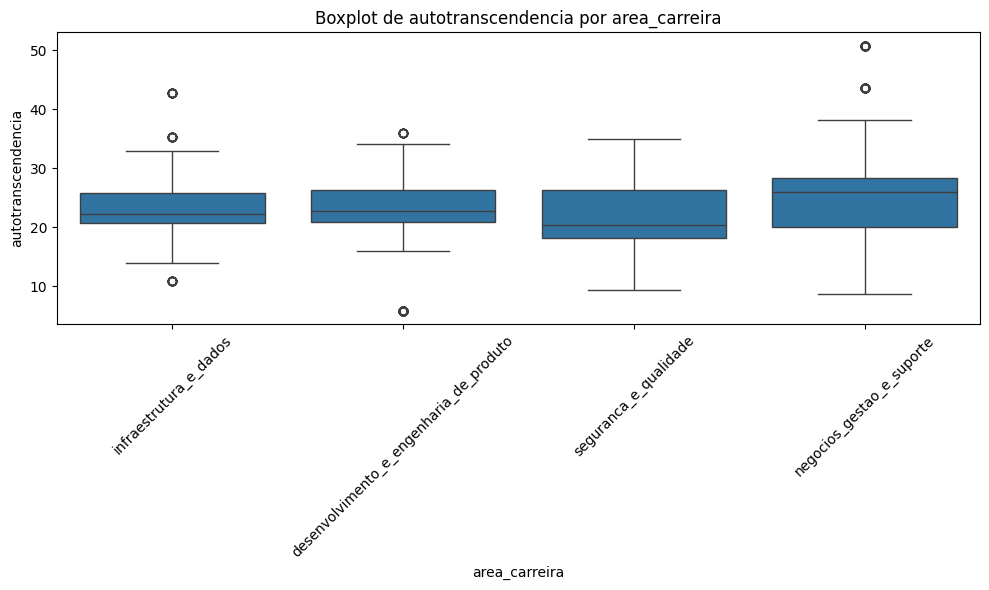

In [ ]:
for col in atributos_numericos:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=rotulo, y=col, data=df_inicial)
    plt.title(f'Boxplot de {col} por {rotulo}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

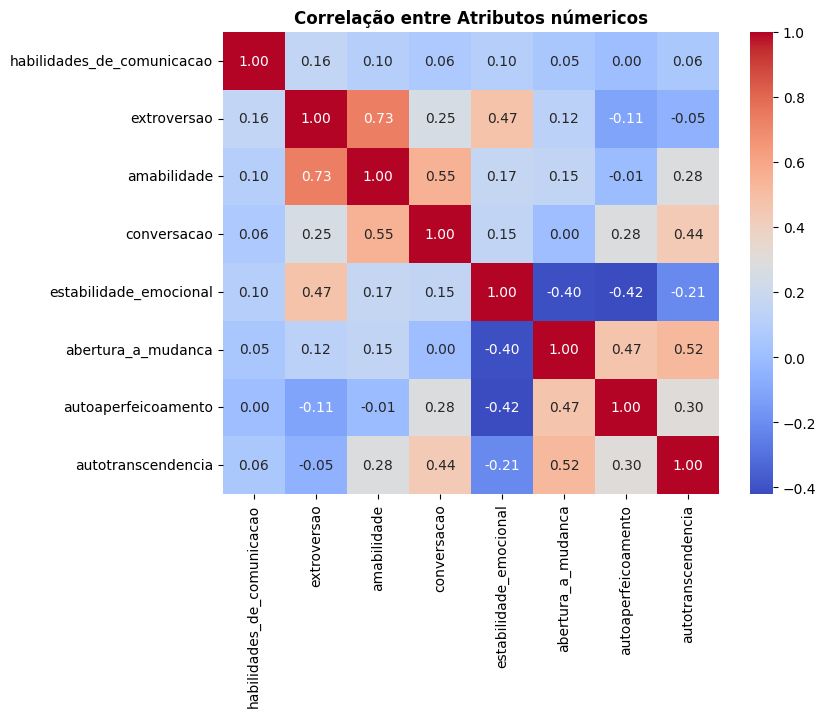

In [ ]:
plt.figure(figsize=(8, 6))  # tamanho do gráfico
matriz_corr = df_inicial[atributos_numericos].corr()
sns.heatmap(
matriz_corr,
annot=True,
cmap='coolwarm',
fmt='.2f'
)
plt.title('Correlação entre Atributos númericos', fontweight='bold')
plt.show()

##3. Pré-processamento

###3.1 Limpeza de dados

In [ ]:
df_inicial = df_inicial.dropna(subset=['area_carreira'])

In [ ]:
df_limpo = df_inicial.dropna(subset=[rotulo])
df_limpo = df_limpo.drop_duplicates()
print("Antes do LabelEncoder, classes únicas:")
display(df_limpo[rotulo].unique())
le = LabelEncoder()
df_limpo[rotulo] = le.fit_transform(df_limpo[rotulo])
print("Classes após LabelEncoder:")
print(le.classes_)

X = df_limpo[atributos_numericos]
y = df_limpo[rotulo]

rus = RandomUnderSampler(random_state=42)
X_balanceado, y_balanceado = rus.fit_resample(X, y)

df_balanceado = pd.DataFrame(X_balanceado, columns=atributos_numericos)
df_balanceado[rotulo] = y_balanceado

print("Classes balanceadas:")
display(df_balanceado[rotulo].value_counts())

print("NAN no rótulo após balanceamento:", df_balanceado[rotulo].isna().sum())

Antes do LabelEncoder, classes únicas:


array(['infraestrutura_e_dados',
       'desenvolvimento_e_engenharia_de_produto', 'seguranca_e_qualidade',
       'negocios_gestao_e_suporte'], dtype=object)

Classes após LabelEncoder:
['desenvolvimento_e_engenharia_de_produto' 'infraestrutura_e_dados'
 'negocios_gestao_e_suporte' 'seguranca_e_qualidade']
Classes balanceadas:


,count
area_carreira,
0,144
1,144
2,144
3,144


NAN no rótulo após balanceamento: 0


In [ ]:
print(df_limpo.dtypes)

habilidades_de_comunicacao    float64
extroversao                   float64
amabilidade                   float64
conversacao                   float64
estabilidade_emocional        float64
abertura_a_mudanca            float64
autoaperfeicoamento           float64
autotranscendencia            float64
area_carreira                   int64
dtype: object


###3.2 Balanceamento dos dados utilizando o RandomUnderSampler.

In [ ]:
X = df_limpo[atributos_numericos]
y = df_limpo[rotulo]
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

In [ ]:
df_balanceado = pd.concat([pd.DataFrame(X_res, columns=atributos_numericos),
                           pd.Series(y_res, name=rotulo).reset_index(drop=True)], axis=1)
print('\nDistribuição original do rótulo:')
display(y.value_counts())
print('\nDistribuição após RandomUnderSampler:')
display(y_res.value_counts())


Distribuição original do rótulo:


,count
area_carreira,
0,382
2,358
1,342
3,144



Distribuição após RandomUnderSampler:


,count
area_carreira,
0,144
1,144
2,144
3,144


###3.3 LabelEncoder()

In [ ]:
le = LabelEncoder()
df_inicial['area_carreira'] = le.fit_transform(df_inicial['area_carreira'])
print(le.classes_)

['desenvolvimento_e_engenharia_de_produto' 'infraestrutura_e_dados'
 'negocios_gestao_e_suporte' 'seguranca_e_qualidade']


In [ ]:
mapa_classes = dict(zip(le.classes_, le.transform(le.classes_)))
print('\nMapeamento label -> número:')
print(mapa_classes)


Mapeamento label -> número:
{'desenvolvimento_e_engenharia_de_produto': np.int64(0), 'infraestrutura_e_dados': np.int64(1), 'negocios_gestao_e_suporte': np.int64(2), 'seguranca_e_qualidade': np.int64(3)}


##4. Divisão de Dados

In [ ]:
# =============================
# Correção robusta: Pré-processamento + Verificação antes do split
# =============================

# (usa as variáveis já existentes: df_inicial, atributos_numericos, rotulo)

# 1) Garantir que df_inicial existe
try:
    df_inicial.shape
except NameError:
    raise RuntimeError("df_inicial não definido — rode a seção de coleta de dados antes.")

# 2) Remover linhas com NaN no rótulo (apenas) e duplicadas -> df_limpo
df_limpo = df_inicial.dropna(subset=[rotulo]).drop_duplicates().reset_index(drop=True)
print("Tamanho df_inicial:", df_inicial.shape)
print("Tamanho df_limpo (sem NaN no rótulo e sem duplicatas):", df_limpo.shape)

# 3) Mostrar se existem NaNs nas colunas de atributos (apenas para inspeção)
nan_atributos = df_limpo[atributos_numericos].isna().sum()
print("\nNaNs por atributo (em df_limpo):")
print(nan_atributos)

# 4) Se houver NaNs em atributos, mostrar algumas linhas problemáticas (opcional)
if df_limpo[atributos_numericos].isna().any().any():
    print("\nAmostra de linhas com NaN em atributos (mostrando até 10):")
    display(df_limpo[df_limpo[atributos_numericos].isna().any(axis=1)].head(10))
    # Remover essas linhas (decisão segura) — com aviso
    print("\nRemovendo linhas com NaN em atributos para evitar problemas.")
    df_limpo = df_limpo.dropna(subset=atributos_numericos).reset_index(drop=True)
    print("Tamanho df_limpo após remover NaNs em atributos:", df_limpo.shape)

# 5) Checar valores únicos do rótulo antes do LabelEncoder
print("\nClasses originais (antes do LabelEncoder):")
display(df_limpo[rotulo].unique())
print("Contagem por classe (antes):")
display(df_limpo[rotulo].value_counts())

# 6) LabelEncoder (aplicar aqui, só no df_limpo limpo)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_limpo[rotulo] = le.fit_transform(df_limpo[rotulo])
print("\nClasses após LabelEncoder:")
print(le.classes_)

# 7) Separar X e y (a partir de df_limpo já limpo e codificado)
X = df_limpo[atributos_numericos].copy()
y = df_limpo[rotulo].copy()

# 8) Verificação final antes do balanceamento
print("\nVerificando NaNs em X e y antes do balanceamento:")
print("NaNs em X:", X.isna().any().any())
print("NaNs em y:", y.isna().sum())

# 9) Balanceamento (RandomUnderSampler)
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

df_balanceado = pd.DataFrame(X_res, columns=atributos_numericos)
df_balanceado[rotulo] = y_res

print("\nDistribuição após RandomUnderSampler:")
display(df_balanceado[rotulo].value_counts())

# 10) Verificação final: certificar que não há NaNs
print("\nNAN no rótulo depois do balanceamento:", df_balanceado[rotulo].isna().sum())
print("NaNs em atributos depois do balanceamento:", df_balanceado[atributos_numericos].isna().any().any())

# 11) Caso ainda exista algum NaN (precaução), remover e avisar
if df_balanceado[rotulo].isna().sum() > 0 or df_balanceado[atributos_numericos].isna().any().any():
    print("\nAVISO: Foram encontrados NaNs mesmo após o balanceamento — removendo linhas afetadas.")
    df_balanceado = df_balanceado.dropna().reset_index(drop=True)
    print("Tamanho df_balanceado após dropna:", df_balanceado.shape)

# 12) Agora sim: divisão treino/teste (80/20) com stratify
from sklearn.model_selection import train_test_split
X = df_balanceado[atributos_numericos]
y = df_balanceado[rotulo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('\nTamanhos:')
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('\ny_train distribuição:')
display(y_train.value_counts())
print('\ny_test distribuição:')
display(y_test.value_counts())


Tamanho df_inicial: (9179, 9)
Tamanho df_limpo (sem NaN no rótulo e sem duplicatas): (1226, 9)

NaNs por atributo (em df_limpo):
habilidades_de_comunicacao    0
extroversao                   0
amabilidade                   0
conversacao                   0
estabilidade_emocional        0
abertura_a_mudanca            0
autoaperfeicoamento           0
autotranscendencia            0
dtype: int64

Classes originais (antes do LabelEncoder):


array([1, 0, 3, 2])

Contagem por classe (antes):


,count
area_carreira,
0,382
2,358
1,342
3,144



Classes após LabelEncoder:
[0 1 2 3]

Verificando NaNs em X e y antes do balanceamento:
NaNs em X: False
NaNs em y: 0

Distribuição após RandomUnderSampler:


,count
area_carreira,
0,144
1,144
2,144
3,144



NAN no rótulo depois do balanceamento: 0
NaNs em atributos depois do balanceamento: False

Tamanhos:
X_train: (460, 8) X_test: (116, 8)

y_train distribuição:


,count
area_carreira,
0,115
3,115
1,115
2,115



y_test distribuição:


,count
area_carreira,
0,29
3,29
2,29
1,29


In [ ]:
X = df_balanceado[atributos_numericos].copy()
y = df_balanceado[rotulo].copy()

# Ensure y is of integer type if it's not already
y = y.astype(int)

# Perform the train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('\nTamanhos:')
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('\ny_train distribuição:')
display(y_train.value_counts())
print('\ny_test distribuição:')
display(y_test.value_counts())


Tamanhos:
X_train: (460, 8) X_test: (116, 8)

y_train distribuição:


,count
area_carreira,
0,115
3,115
1,115
2,115



y_test distribuição:


,count
area_carreira,
0,29
3,29
2,29
1,29


In [ ]:
df_balanceado[rotulo].isna().sum()


np.int64(0)

##5. Construção dos modelos e treinos

###5.1 Instanciando o objeto DecisionTreeClassifier

In [ ]:
clf = DecisionTreeClassifier(random_state=42)

###5.2 Dicionário param_grid_ad e afeições seguintes com o mesmo

In [ ]:
param_grid_ad = {
'criterion': ['gini', 'entropy'],
'max_depth': [None, 5, 10, 15],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid_search_ad = GridSearchCV(estimator=clf, param_grid=param_grid_ad, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

In [ ]:
grid_search_ad.fit(X_train, y_train)


print('\nMelhores parâmetros encontrados:')
print(grid_search_ad.best_params_)
print('\nMelhor score (cv):', grid_search_ad.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Melhores parâmetros encontrados:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Melhor score (cv): 0.8782608695652174


###5.3 Desenho da Árvore de Decisão com o método plot_tree()

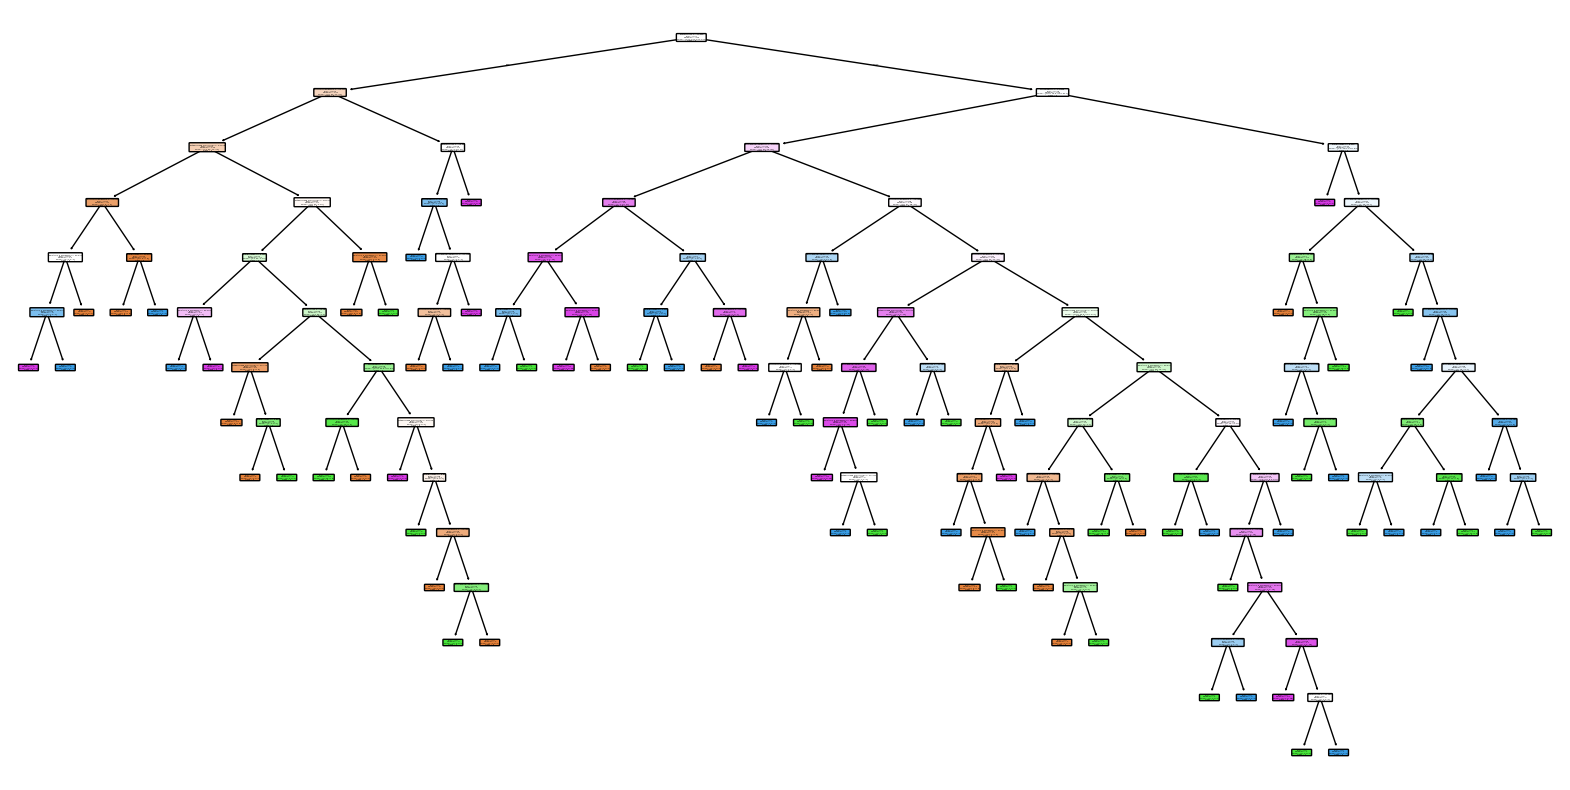

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(grid_search_ad.best_estimator_, feature_names=atributos_numericos, class_names=[str(c) for c in le.classes_], filled=True, rounded=True)
plt.show()

In [ ]:
y_pred = grid_search_ad.predict(X_test)
print('\nClassification report (test set):')
print(classification_report(y_test, y_pred))



Classification report (test set):
              precision    recall  f1-score   support

           0       1.00      0.66      0.79        29
           1       0.93      0.97      0.95        29
           2       0.83      1.00      0.91        29
           3       0.91      1.00      0.95        29

    accuracy                           0.91       116
   macro avg       0.92      0.91      0.90       116
weighted avg       0.92      0.91      0.90       116



In [ ]:
print(le.classes_)

[0 1 2 3]


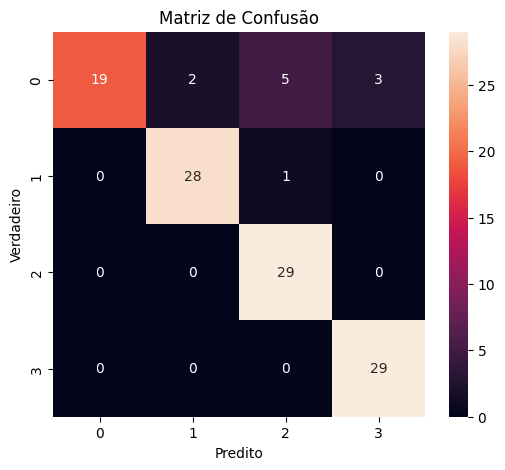

In [ ]:
#conferindo a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

##6. Predição do novo estudante

###6.1 Função para a predição

In [ ]:
def predizer_novo_estudante(new_student_values):
#Recebe lista/array com 8 valores (mesma ordem que atributos_numericos) e retorna a classe predita (string).
  arr = np.array(new_student_values).reshape(1, -1)
  pred_num = grid_search_ad.predict(arr)
  pred_label = le.inverse_transform(pred_num)
  return pred_label[0]


# Exemplo de uso
exemplo = X_test.iloc[0].tolist()
print('\nExemplo de predicao com primeira amostra de X_test:')
print('Valores:', exemplo)
print('Predição (classe):', predizer_novo_estudante(exemplo))

#INSTRUÇÕES DE USO DA PREDIÇÃO
# Para entrada manual (descomente e modifique):
# novo = [40, 50.0, 8.5, 7.2, 60.0, 35.0, 25.0, 20.0]
# print('Predição para novo estudante:', predizer_novo_estudante(novo))





Exemplo de predicao com primeira amostra de X_test:
Valores: [40.0, 21.378830200000003, 8.8939597, 7.192968700000001, 51.6116998, 28.436507700000003, 29.0588483, 27.9883781]
Predição (classe): 0


###6.2 Digitação dos valores do aluno após a consulta psicológica (sIMU

In [ ]:
'''
Imagine que o aluno responde o formulário psicológico e os resultados são:

habilidade_de_conversacao = 40.0

extroversao = 21.3

amabilidade = 8.9

conversacao = 7.1

estabilidade_emocional = 51.6

abertura_a_mudanca = 28.4

autoaperfeicoamento = 29.0

autotranscedencia = 27.9
'''

print("****     Predição de Novo Estudante     ****")
print("Digite os 8 valores numéricos referentes aos atributos do estudante.\n")

valores = []
for atributo in atributos_numericos:
    valor = float(input(f"Digite o valor para '{atributo}': "))
    valores.append(valor)

classe_predita = predizer_novo_estudante(valores)

print("\n=== Resultado da Predição ===")
print("Classe prevista:", classe_predita)


****     Predição de Novo Estudante     ****
Digite os 8 valores numéricos referentes aos atributos do estudante.

Digite o valor para 'habilidades_de_comunicacao': 40
Digite o valor para 'extroversao': 21.3
Digite o valor para 'amabilidade': 8.9
Digite o valor para 'conversacao': 7.1
Digite o valor para 'estabilidade_emocional': 51.6
Digite o valor para 'abertura_a_mudanca': 28.4
Digite o valor para 'autoaperfeicoamento': 29
Digite o valor para 'autotranscendencia': 27.9

=== Resultado da Predição ===
Classe prevista: 0


In [ ]:
#Verificação da acurácia do modelo

y_pred = grid_search_ad.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.66      0.79        29
           1       0.93      0.97      0.95        29
           2       0.83      1.00      0.91        29
           3       0.91      1.00      0.95        29

    accuracy                           0.91       116
   macro avg       0.92      0.91      0.90       116
weighted avg       0.92      0.91      0.90       116

